# InfographicVQA Visual Question Answering Benchmark Analysis

Executive Summary

**Dataset:** InfographicVQA_mini - Infographic Visual Question Answering  
**Total Samples:** 500 infographic Q&A pairs per phase  
**Task:** Answer questions about infographic images (charts, statistics, visual design)  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

## Benchmark Structure

### $QA_{\text{OCR}}$: OCR parsing → LLM QA
**Strategy:** Separate OCR extraction → LLM answers question based on extracted text

- **$QA_{\text{OCR}}^{\text{simple}}$:** Azure Intelligence OCR + GPT-5-mini QA (simple prompt)
- **$QA_{\text{OCR}}^{\text{generic}}$:** Mistral OCR 2 OCR + GPT-5-mini QA (generic prompt)
- **$QA_{\text{OCR}}^{\text{task-aware}}$:** Azure Intelligence OCR + GPT-5-mini QA (task-aware prompt)

**Model Format:** `{parsing_model}__{qa_model}` (e.g., `azure_intelligence__gpt-5-mini`)

### $QA_{\text{VLM-2stage}}$: VLM parsing → LLM QA
**Strategy:** Same VLM does both parsing and question answering

- **$QA_{\text{VLM-2stage}}^{\text{cot}}$:** GPT-5-mini does parsing + QA (CoT prompt)
- **$QA_{\text{VLM-2stage}}^{\text{generic+cot}}$:** GPT-5-nano does parsing + QA (generic + CoT)
- **$QA_{\text{VLM-2stage}}^{\text{sonnet}}$:** Claude Sonnet does parsing + QA

**Model Format:** `{model}__{model}` (e.g., `claude_sonnet__claude_sonnet`)

### $QA_{\text{VLM-direct}}$: Direct VLM QA
**Strategy:** VLM sees image directly and answers question

- **$QA_{\text{VLM-direct}}^{\text{sonnet}}$:** Claude Sonnet direct VQA
- **$QA_{\text{VLM-direct}}^{\text{multi}}$:** GPT-5-mini, GPT-5-nano, Claude Sonnet direct VQA

**Model Format:** `{model}` (e.g., `claude_sonnet`)

### $QA_{\text{special}}$: Special Strategy
**Strategy:** Experimental approaches for infographics

- **$QA_{\text{special}}^{a}$:** Special strategy variant A
- **$QA_{\text{special}}^{b}$:** Special strategy variant B
- **$QA_{\text{special}}^{c}$:** Special strategy variant C

# 1. Imports and Metadata

In [53]:
# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'mistral_ocr_3', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral OCR 2',
        'mistral_ocr_3': 'Mistral OCR 3',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)

def get_phase_group(phase: str) -> str:
    """Get phase group with formal notation."""
    if phase.startswith('QA1'):
        return '$QA_{\\text{OCR}}$'
    elif phase.startswith('QA2'):
        return '$QA_{\\text{VLM-2stage}}$'
    elif phase.startswith('QA3'):
        return '$QA_{\\text{VLM-direct}}$'
    elif phase.startswith('QA4'):
        return '$QA_{\\text{special}}$'
    return 'Unknown'

def get_phase_formal_name(phase: str) -> str:
    """Get formal mathematical name for a specific phase."""
    phase_mapping = {
        'QA1a': '$QA_{\\text{OCR}}^{\\text{simple}}$',
        'QA1b': '$QA_{\\text{OCR}}^{\\text{generic}}$',
        'QA1c': '$QA_{\\text{OCR}}^{\\text{task-aware}}$',
        'QA2a': '$QA_{\\text{VLM-2stage}}^{\\text{cot}}$',
        'QA2b': '$QA_{\\text{VLM-2stage}}^{\\text{generic+cot}}$',
        'QA2c': '$QA_{\\text{VLM-2stage}}^{\\text{sonnet}}$',
        'QA3a': '$QA_{\\text{VLM-direct}}^{\\text{sonnet}}$',
        'QA3b': '$QA_{\\text{VLM-direct}}^{\\text{multi}}$',
        'QA4a': '$QA_{\\text{special}}^{a}$',
        'QA4b': '$QA_{\\text{special}}^{b}$',
        'QA4c': '$QA_{\\text{special}}^{c}$',
    }
    return phase_mapping.get(phase, phase)

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

## 2. Dataset Explorer

Load all phase files and explore the InfographicVQA dataset structure.

In [54]:
# Define paths
RESULTS_DIR = Path("../../2_clean/InfographicVQA_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv
  - QA4a.csv
  - QA4b.csv
  - QA4c.csv


In [55]:
# Dataset configuration
DATASET_NAME = "InfographicVQA_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: InfographicVQA_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA1a, QA2a, QA1b, QA1c, QA3a, QA3b, QA4b, QA2b, QA4a, QA4c, QA2c


In [56]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for InfographicVQA (11 phases including QA4)
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b', 'QA4a', 'QA4b', 'QA4c']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 500 samples, 16 columns
QA1b: 500 samples, 16 columns
QA1c: 500 samples, 16 columns
QA2a: 500 samples, 16 columns
QA2b: 500 samples, 16 columns
QA2c: 500 samples, 64 columns
QA3a: 500 samples, 16 columns
QA3b: 500 samples, 16 columns
QA4a: 500 samples, 8 columns
QA4b: 500 samples, 8 columns
QA4c: 500 samples, 8 columns

Total phases loaded: 11


In [57]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2c columns:
  M

In [58]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 426/500 (85.2%)
    ⚠️  Empty predictions: 74
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 456/500 (91.2%)
    ⚠️  Empty predictions: 44
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 464/500 (92.8%)
    ⚠️  Empty predictions: 36

📊 QA1b - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 441/500 (88.2%)
    ⚠️  Empty predictions: 59
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 491/500 (98.2%)
    ⚠️  Empty predictions: 9
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 495/500 (99.0%)
    ⚠️  Empty predictions: 5

📊 QA1c - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 402/500 (80.4%)
    ⚠️  Empty predictions: 98
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 467/500 (93.4%)
    ⚠️  Empty predictions: 33
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 458/500 (91.6%)
    ⚠️  Empty predictions: 42

📊 QA2a - Total rows: 500
  cl

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
26,QA2c,in_ground_truth_in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini,500,0,500,0,0.0
25,QA2c,in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini.1,500,0,500,0,0.0
24,QA2c,in_ground_truth_in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini,500,0,500,0,0.0
23,QA2c,in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini.1,500,0,500,0,0.0
22,QA2c,in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini,500,0,500,0,0.0
20,QA2c,in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini,500,0,500,0,0.0
35,QA4c,gpt-5-mini,500,375,125,0,75.0
6,QA1c,azure_intelligence__gpt-5-mini,500,402,98,0,80.4
33,QA4a,gpt-5-mini,500,404,96,0,80.8
30,QA3b,claude_sonnet,500,422,78,0,84.4



⚠️  Found 32 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 3. Dataset Statistics

Analyze question and answer characteristics.

In [59]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 500

Question Length (characters):
  Mean: 64.5 characters
  Median: 61.0 characters
  Min: 13 characters
  Max: 180 characters

Question Length (words):
  Mean: 11.1 words
  Median: 11.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.29
  Median answers per question: 1
  Max answers for a single question: 5

Average Answer Length (characters):
  Mean: 8.2 characters
  Median: 5.0 characters
  Min: 1.0 characters
  Max: 66.0 characters


## Metric calculation

In [60]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager,
    parsed_data: str = None
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'gt_in_parsed': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    # Check if ground truth appears in parsed data
    gt_in_parsed = 0.0
    if parsed_data:
        parsed_str = str(parsed_data).lower()
        for gt in ground_truths:
            if gt.lower() in parsed_str:
                gt_in_parsed = 1.0
                break
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
        'gt_in_parsed': gt_in_parsed,
    }

# Calculate metrics for all phases and models
metrics_results = {}


## 5. Metrics Summary

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [61]:
# Create a summary DataFrame
summary_data = []

for strategy, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': strategy,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'GT in Parsed Data': metrics.get('gt_in_parsed', 0.0),
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)


print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per strategy (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    print(f"  {strategy}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)


KeyError: 'Phase'

### Sample Preview

Display 10 random Q&A samples from 3 different models.

In [ ]:
# Display 10 random samples with requested format
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_samples = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Get 10 random samples
    random_samples = df_samples.sample(n=min(10, len(df_samples)), random_state=42)
    
    print(f"📋 10 Random Samples from {analysis_phase} - Model: {get_model_display_name(first_model)}")
    print("=" * 120)
    
    for sample_num, (_, row) in enumerate(random_samples.iterrows(), 1):
        ground_truths = parse_ground_truths(row['ground_truths'])
        prediction = str(row[f'prediction_{first_model}'])
        
        # Calculate metrics
        gt_in_pred_score = compute_ground_truth_in_prediction(prediction, ground_truths)
        anls_score = compute_anls(prediction, ground_truths, threshold=0.5)
        exact_match_score = compute_exact_match(prediction, ground_truths)
        cosine_sim_score = embedding_manager.compute_cosine_similarity(
            phase=analysis_phase,
            ground_truth=ground_truths[0],
            prediction=prediction,
            sample_id=row['sample_id'],
            model=first_model
        )
        
        # Format output as requested
        print(f"\nSample {sample_num}: GT_in_pred: {gt_in_pred_score:.4f}, ANLS: {anls_score:.4f}")
        print(f"Cosine Similarity: {cosine_sim_score:.4f}")
        print(f"Exact Match: {exact_match_score:.4f}")
        print(f"Question: {row['question']}")
        print(f"Ground Truth: {ground_truths[0] if ground_truths else 'N/A'}")
        print(f"Prediction: {prediction}")
        print("-" * 120)


Identical embeddings for sample infovqa_mini_0073, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0374, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0394, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0450, model azure_intelligence__gpt-5-mini


📋 10 Random Samples from QA1a - Model: Azure Intelligence → GPT-5 Mini

Sample 1: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 0.7026
Exact Match: 1.0000
Question: Which is the IOT application shown in the infographic in green background color?
Ground Truth: whatsapp
Prediction: WhatsApp
------------------------------------------------------------------------------------------------------------------------

Sample 2: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Question: What percentage of respondents backup photos on cloud according to the survey?
Ground Truth: 45.3%
Prediction: 45.3%
------------------------------------------------------------------------------------------------------------------------

Sample 3: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Question: What is the ticket price (in dollars) for the quarter-finals of the 2015 ICC Cricket World Cup?
Ground Truth: $50.87
Prediction: $50.87
---------

## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

In [ ]:
# Bar charts for each metric (PRIMARY METRIC FIRST) - one figure per strategy
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#16a085', '#c0392b']

for strategy in strategies:
    # Filter data for this strategy
    strategy_df = summary_df[summary_df['Strategy'] == strategy]
    
    if len(strategy_df) == 0:
        print(f"No data for {strategy}")
        continue
    
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(24, 6))
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Prepare data: sort models and plot
        plot_data = strategy_df.sort_values('Model', key=lambda x: x.map(lambda m: sort_models([m])[0]))
        
        bars = ax.bar(range(len(plot_data)), plot_data[metric], color=colors_palette[idx], alpha=0.85, width=0.7)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric}', 
                     fontsize=14 if metric == 'GT in Pred' else 12, 
                     fontweight='bold', pad=12)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in plot_data['Model']], rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
    
    plt.suptitle(f'Metrics Summary for {strategy}', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


No data for QA1 (OCR+VLM)
No data for QA2 (VLM Parse+QA)
No data for QA3 (Direct VQA)

🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

In [ ]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Strategy {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Strategy': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots - one figure per strategy (QA1, QA2, QA3)
metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
strategies_list = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']

for strategy in strategies_list:
    # Filter data for this strategy
    strategy_phases = [p for p in sample_metrics_df['Strategy'].unique() if get_phase_strategy(p) == strategy]
    strategy_data = sample_metrics_df[sample_metrics_df['Strategy'].isin(strategy_phases)]
    
    if len(strategy_data) == 0:
        continue
    
    fig, axes = plt.subplots(1, len(metrics_for_boxplot), figsize=(22, 6))
    
    for idx, metric in enumerate(metrics_for_boxplot):
        ax = axes[idx]
        
        # Sort models
        strategy_data_sorted = strategy_data.copy()
        strategy_data_sorted['Model'] = pd.Categorical(
            strategy_data_sorted['Model'],
            categories=sort_models(strategy_data_sorted['Model'].unique().tolist()),
            ordered=True
        )
        
        sns.boxplot(data=strategy_data_sorted, x='Model', y=metric, hue='Strategy', ax=ax, palette='Set2')
        
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} Distribution', 
                    fontsize=14 if metric == 'GT in Pred' else 13, 
                    fontweight='bold', pad=12)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(title='Phase', loc='best', fontsize=9)
        ax.set_ylim(-0.05, 1.05)
    
    plt.suptitle(f'Metrics Distribution for {strategy}', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

Calculating per-sample metrics for box plots (using only valid rows)...


Strategy QA1a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0027, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 

Strategy QA1b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0042, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0048, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0057, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0058, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0082, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 

...

Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0009, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0025, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0043, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0048, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0056, model gpt-5-mini
Identical embeddings for sample infovqa_mini_005

Strategy QA4b:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0011, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0026, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0050, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0057, model gpt-5-mini
Identical embeddings for sample infovqa_mini_006

Strategy QA4c:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0009, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0026, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0049, model gpt-5-mini
Identical embeddings for sample infovqa_mini_005

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

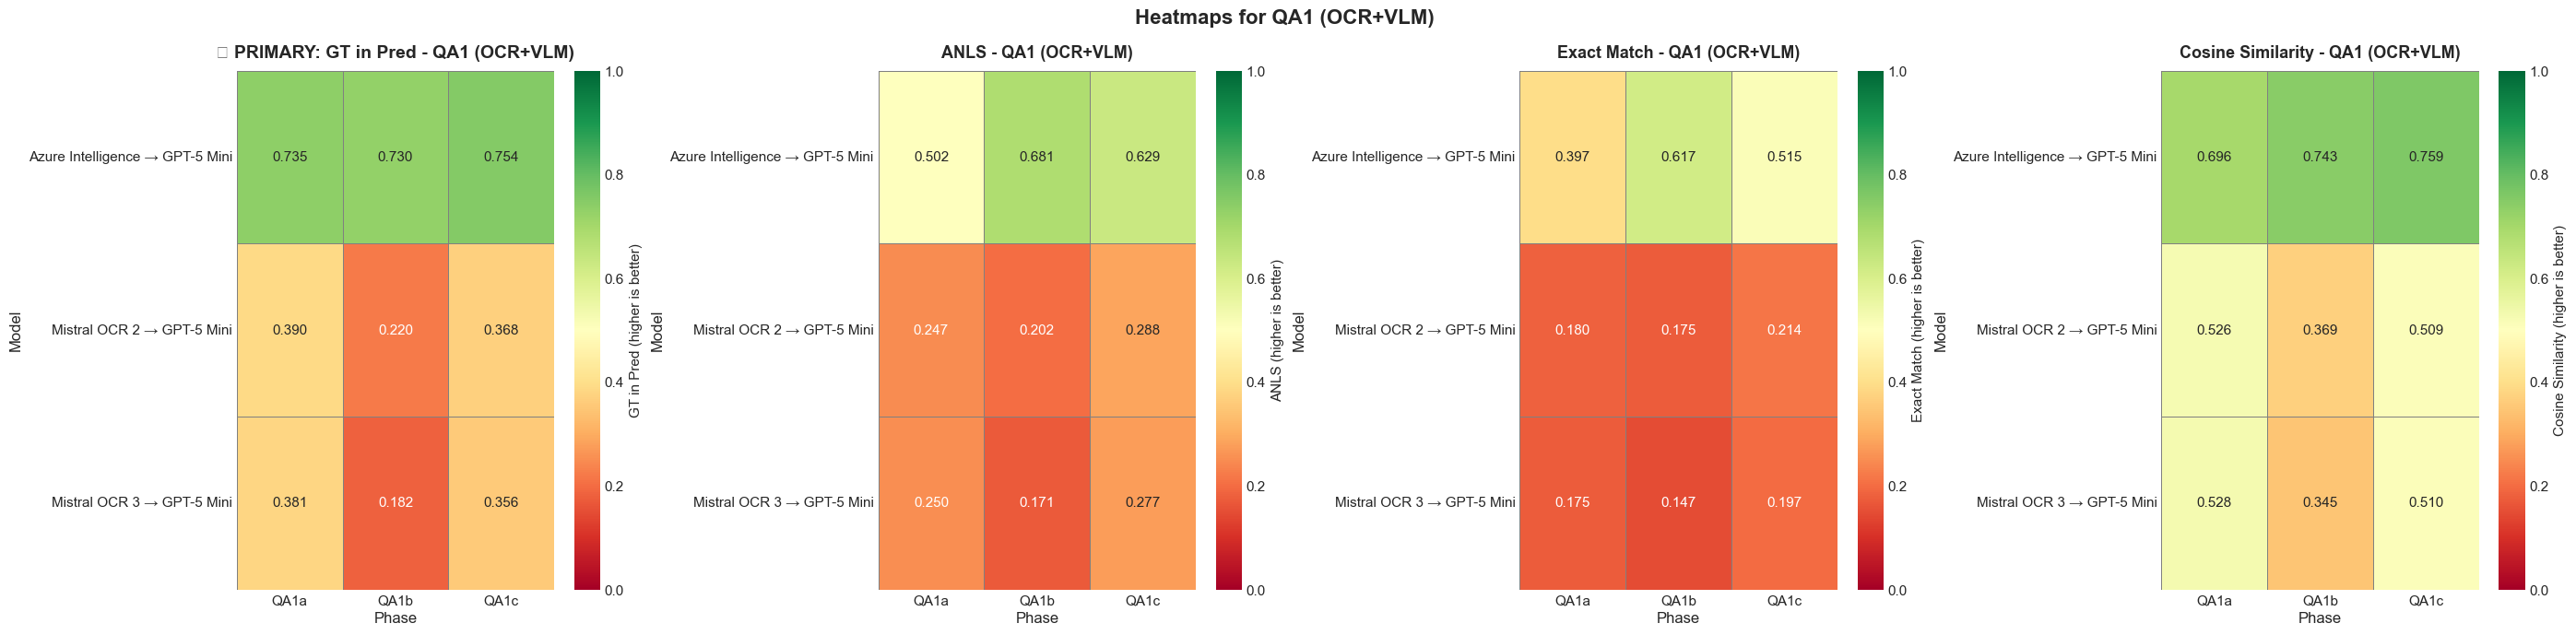

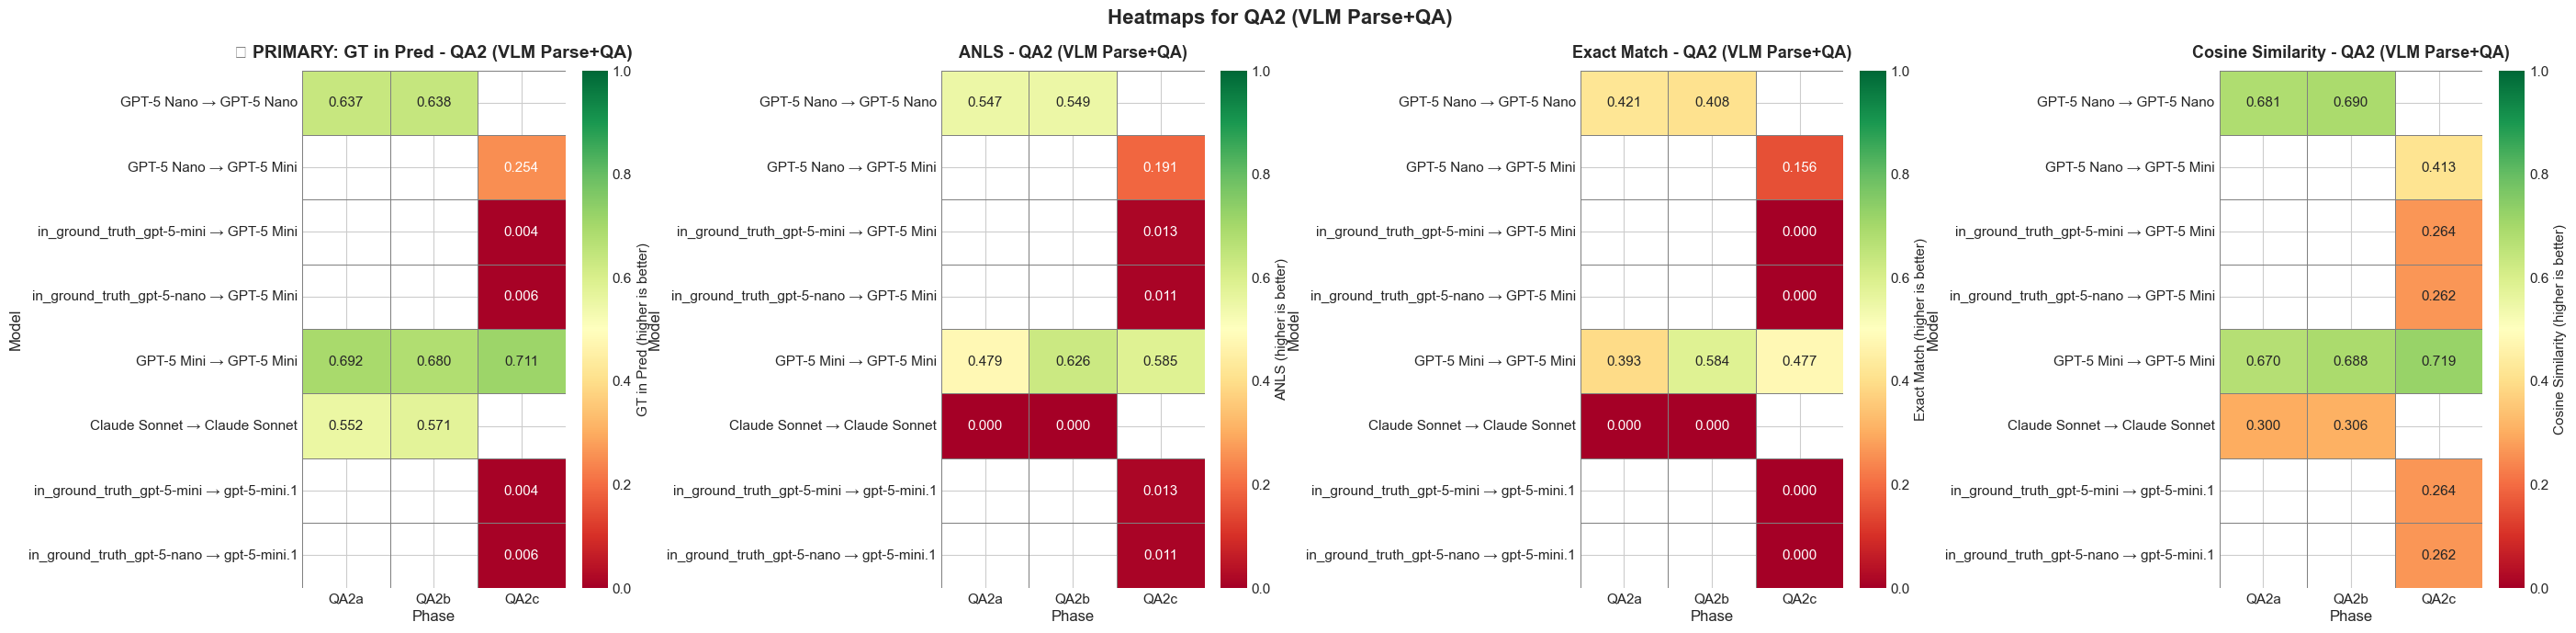

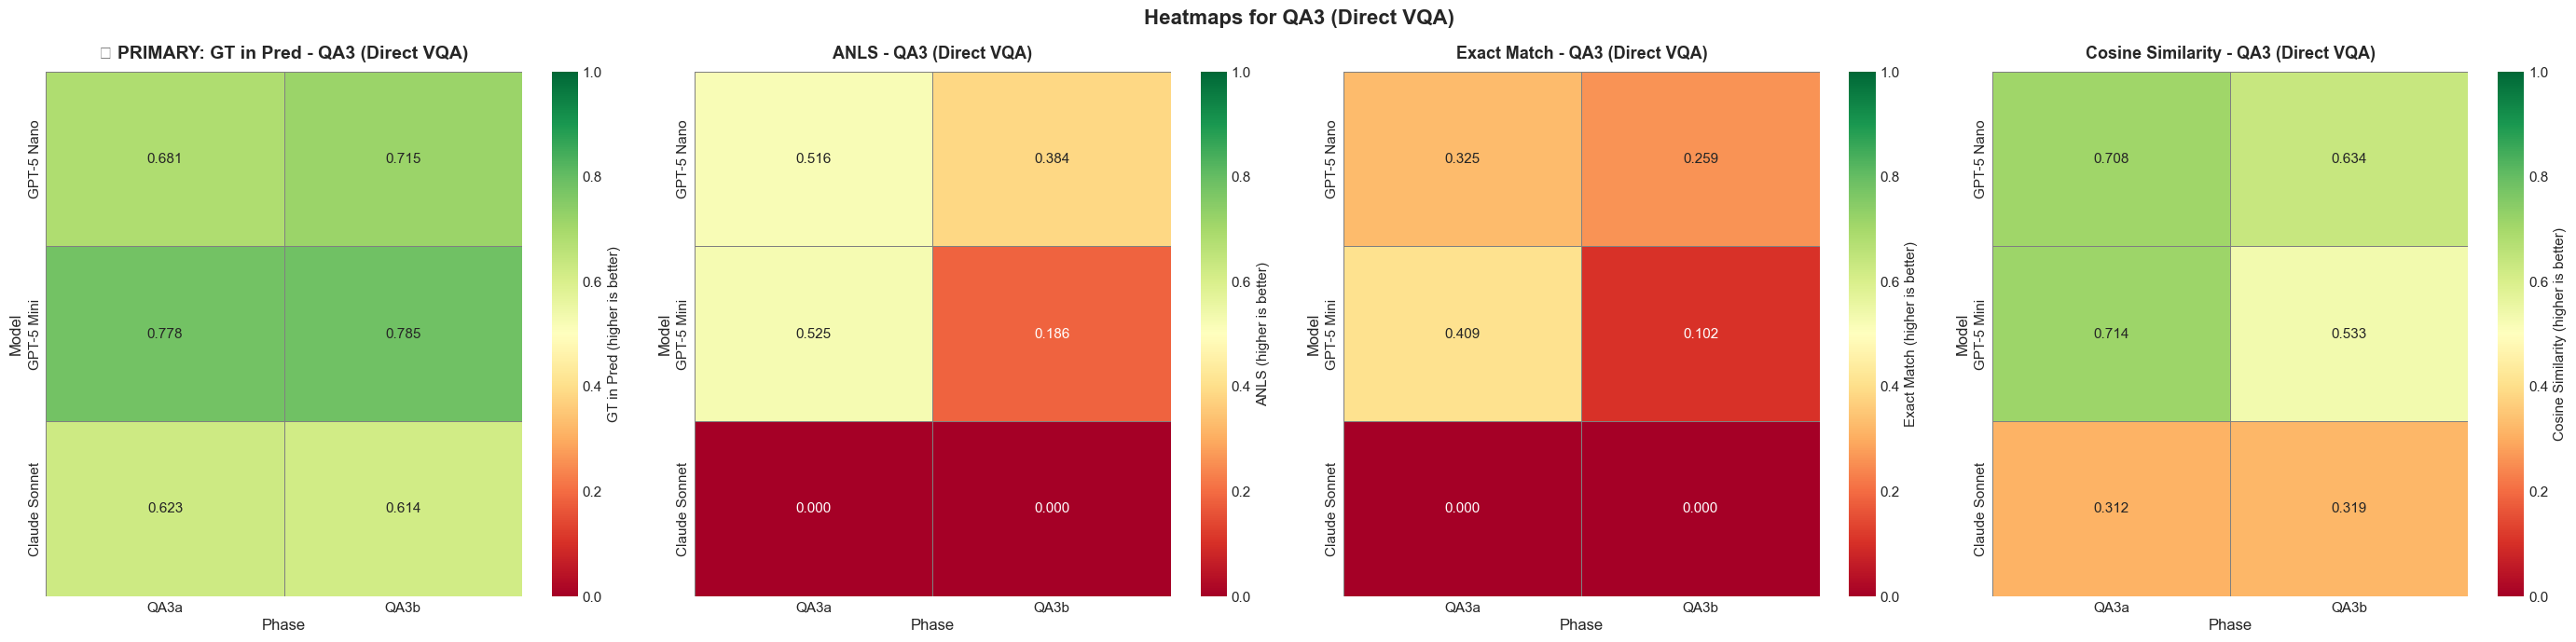


🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance for each strategy


In [ ]:
# Create separate heatmaps for QA1, QA2, and QA3 strategies
strategies_to_plot = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']

for strategy_name, phases in strategies_to_plot.items():
    fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))
    
    if len(metrics_to_show) == 1:
        axes = [axes]
    
    for idx, metric_name in enumerate(metrics_to_show):
        ax = axes[idx]
        
        # Filter data for this strategy's phases
        strategy_data = {phase: metrics_results[phase] for phase in phases if phase in metrics_results}
        
        # Create heatmap data: rows = models, columns = phases
        heatmap_data = []
        model_names = []
        
        # Get all unique models across the filtered phases and sort them
        all_models = set()
        for phase_models in strategy_data.values():
            all_models.update(phase_models.keys())
        all_models = sort_models(list(all_models))
        
        # Build heatmap data
        for model in all_models:
            row_data = []
            for phase in phases:
                if phase in strategy_data and model in strategy_data[phase]:
                    # Map metric name to key
                    metric_key = metric_name.lower().replace(' ', '_')
                    value = strategy_data[phase][model].get(metric_key, np.nan)
                    row_data.append(value)
                else:
                    row_data.append(np.nan)
            
            heatmap_data.append(row_data)
            model_names.append(model)
        
        heatmap_df = pd.DataFrame(
            heatmap_data,
            index=[get_model_display_name(m) for m in model_names],
            columns=phases
        )
        
        # Use colormap: green for good, red for bad (all QA metrics: higher is better)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
        
        sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                    ax=ax, cbar_kws={'label': cbar_label}, 
                    vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
        
        # Emphasize primary metric in title
        title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric_name} - {strategy_name}', 
                    fontsize=14 if metric_name == 'GT in Pred' else 13, 
                    fontweight='bold', pad=10)
        ax.set_xlabel('Phase', fontsize=12)
        ax.set_ylabel('Model', fontsize=12)
    
    plt.suptitle(f'Heatmaps for {strategy_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance for each strategy")

In [ ]:
# Compare best models from each strategy (QA1, QA2, QA3) by GT in Pred
best_models = {}

for strategy in ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']:
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    best_models[strategy] = best_model

# Create comparison DataFrame
comparison_df = pd.DataFrame(best_models).T
comparison_df = comparison_df[['Model', 'GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']]

print("🏆 Best Model Comparison Across Strategies (by GT in Pred)")
display(comparison_df)

# Separate bar charts for each metric
metrics = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
if len(metrics) == 1:
    axes = [axes]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    comparison_df.set_index('Model')[metric].plot(
        kind='bar', ax=ax, color=colors[idx], alpha=0.85, width=0.8
    )
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric} by Strategy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Strategy', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels([s.split(' (')[0] for s in comparison_df.index], rotation=0)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


ValueError: attempt to get argmax of an empty sequence

## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.

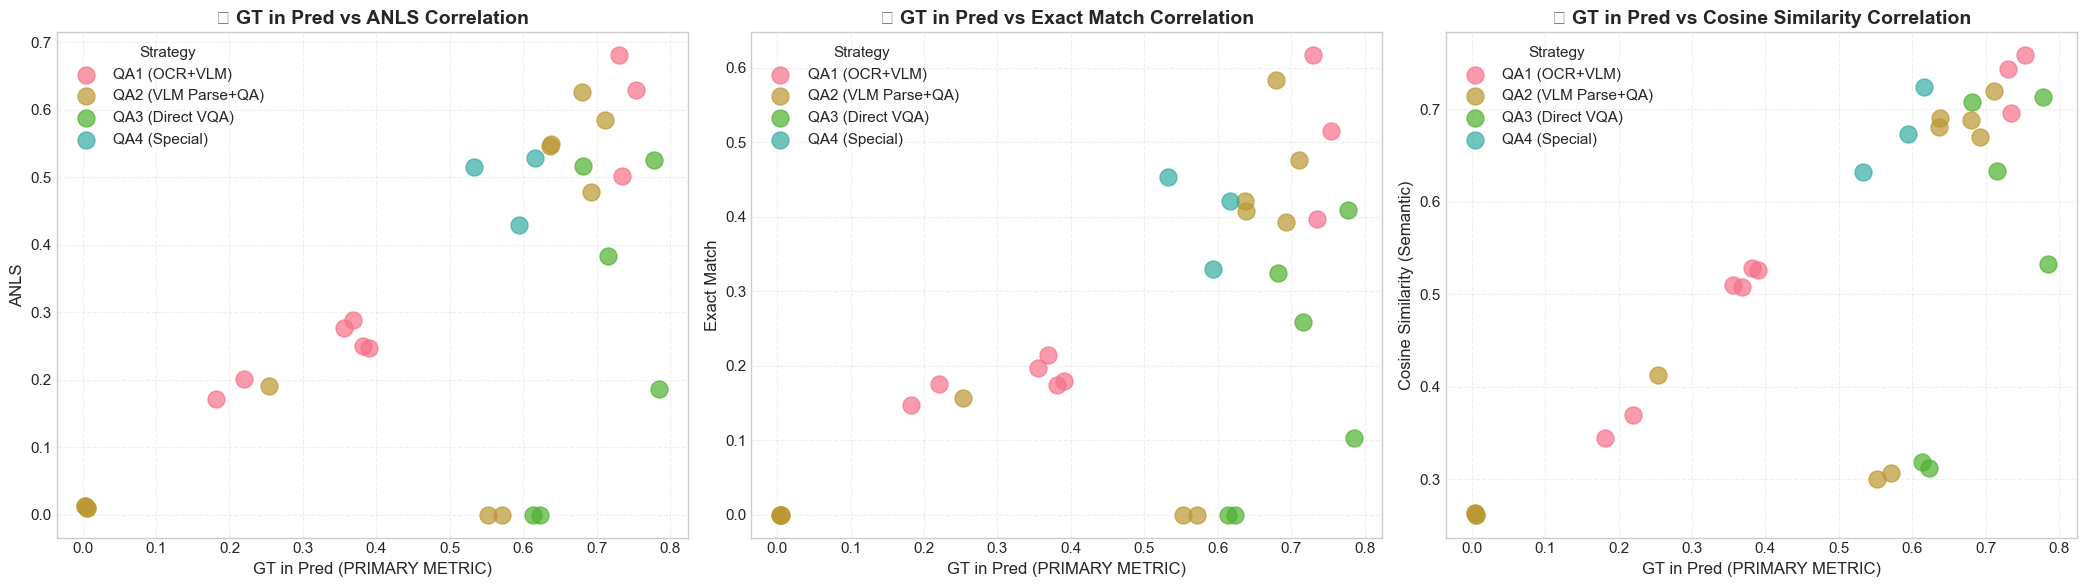


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [ ]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

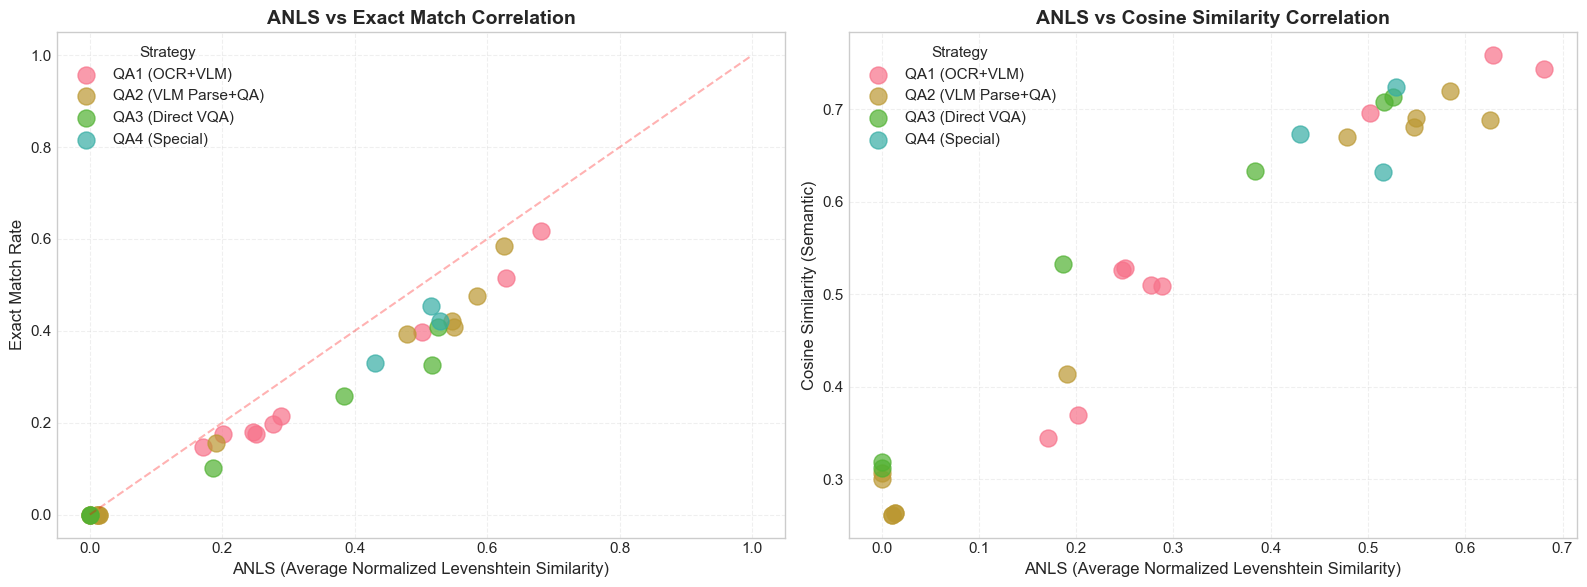

In [ ]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.

## 10.5 Ground Truth in Parsed Data Analysis

Heatmap visualization for "Ground Truth in Parsed Data" metric across all experiments.


In [ ]:
# Ground Truth in Parsed Data heatmap
print("\n" + "="*100)
print("GROUND TRUTH IN PARSED DATA - Heatmap Analysis")
print("="*100)
print("\nThis metric indicates the percentage of samples where the ground truth appears in the parsed/extracted data.")
print("High values suggest the OCR/parsing step successfully extracted relevant information.\n")

# Define strategies and their phases
strategy_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b'],
    'QA4 (Special)': ['QA4a', 'QA4b', 'QA4c']
}

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Ground Truth in Parsed Data - {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases in this strategy
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_phase_names
    )
    
    # Print the table
    print(f"\nGround Truth in Parsed Data - {strategy_name}:")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use colormap: green for good, red for bad
    cmap = 'RdYlGn'
    cbar_label = 'GT in Parsed Data (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'Ground Truth in Parsed Data - {strategy_name}', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*100)


Question Type Distribution (QA1a):
  What           :  205 questions ( 41.0%)
  Which          :  116 questions ( 23.2%)
  How            :   84 questions ( 16.8%)
  Other          :   49 questions (  9.8%)
  Who            :   22 questions (  4.4%)
  When           :   16 questions (  3.2%)
  Where          :    8 questions (  1.6%)


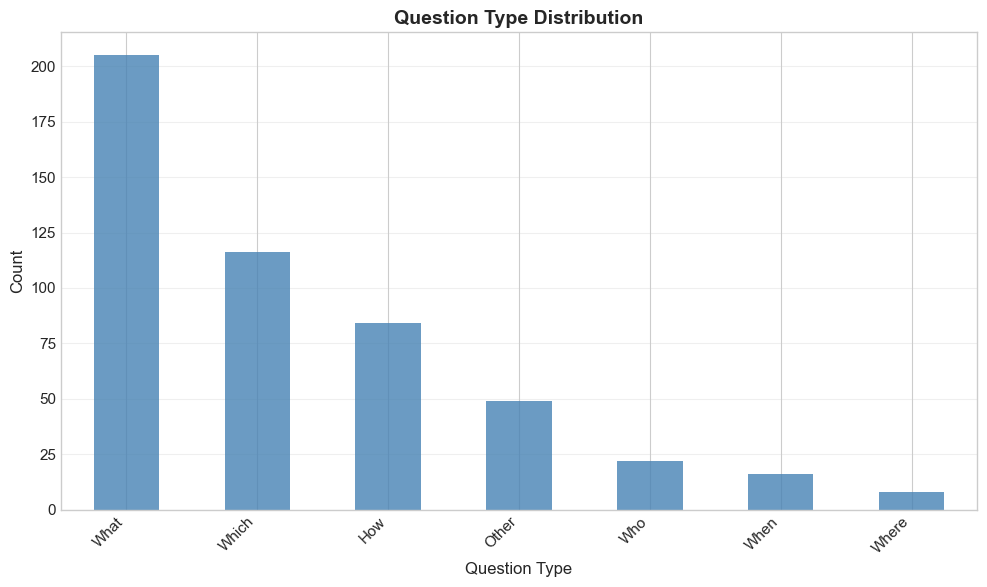

In [ ]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

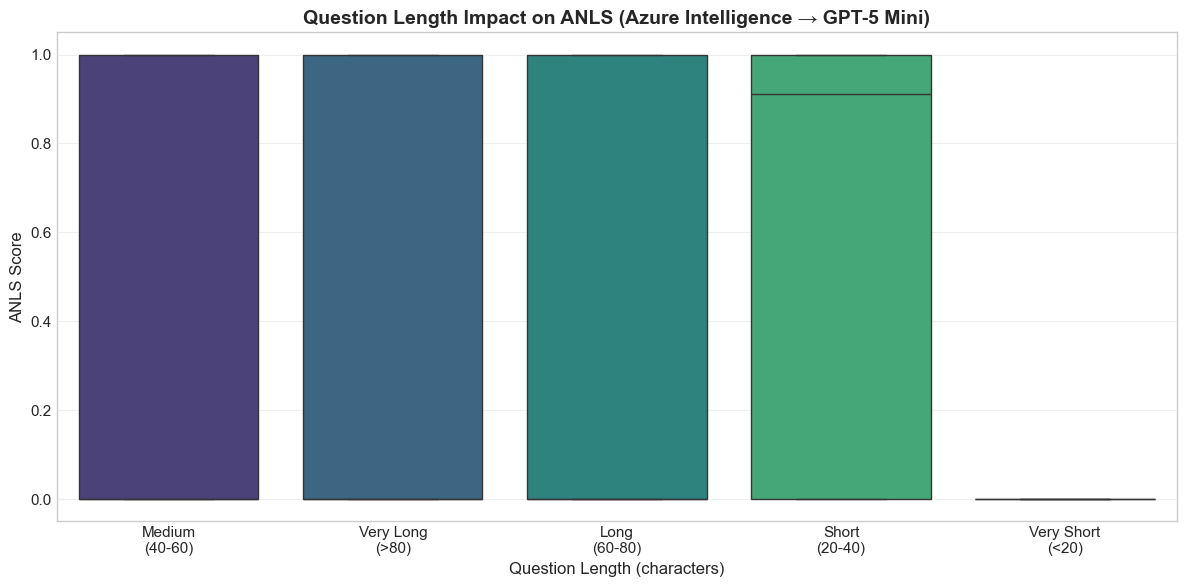

In [ ]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

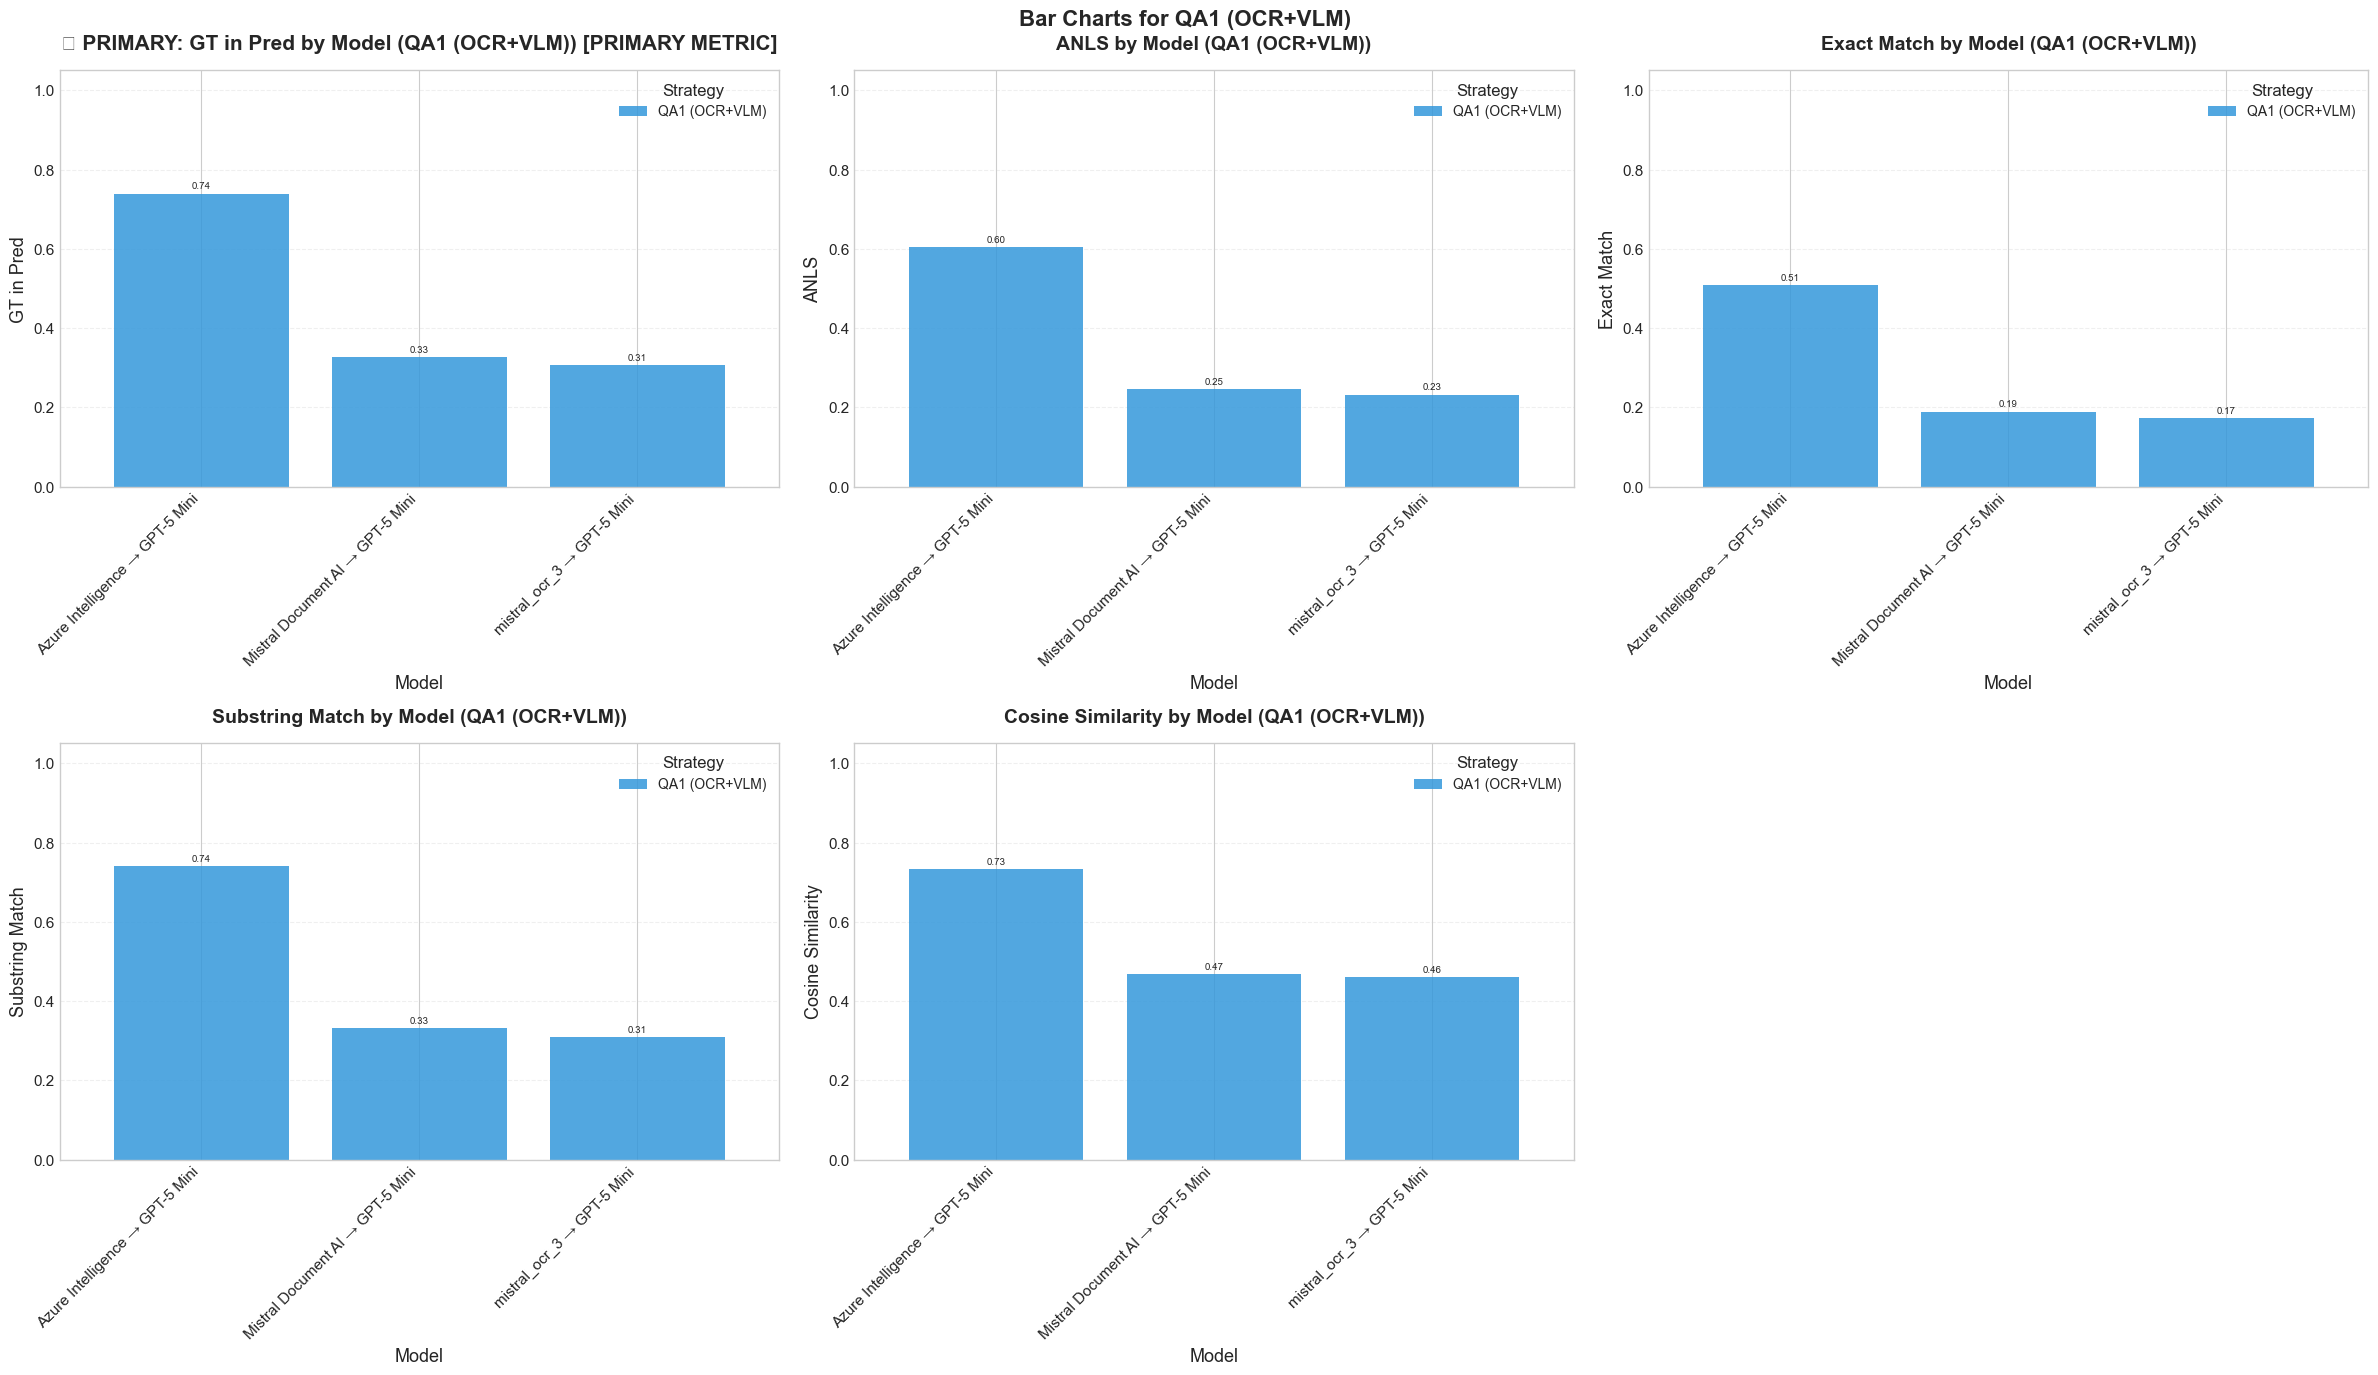

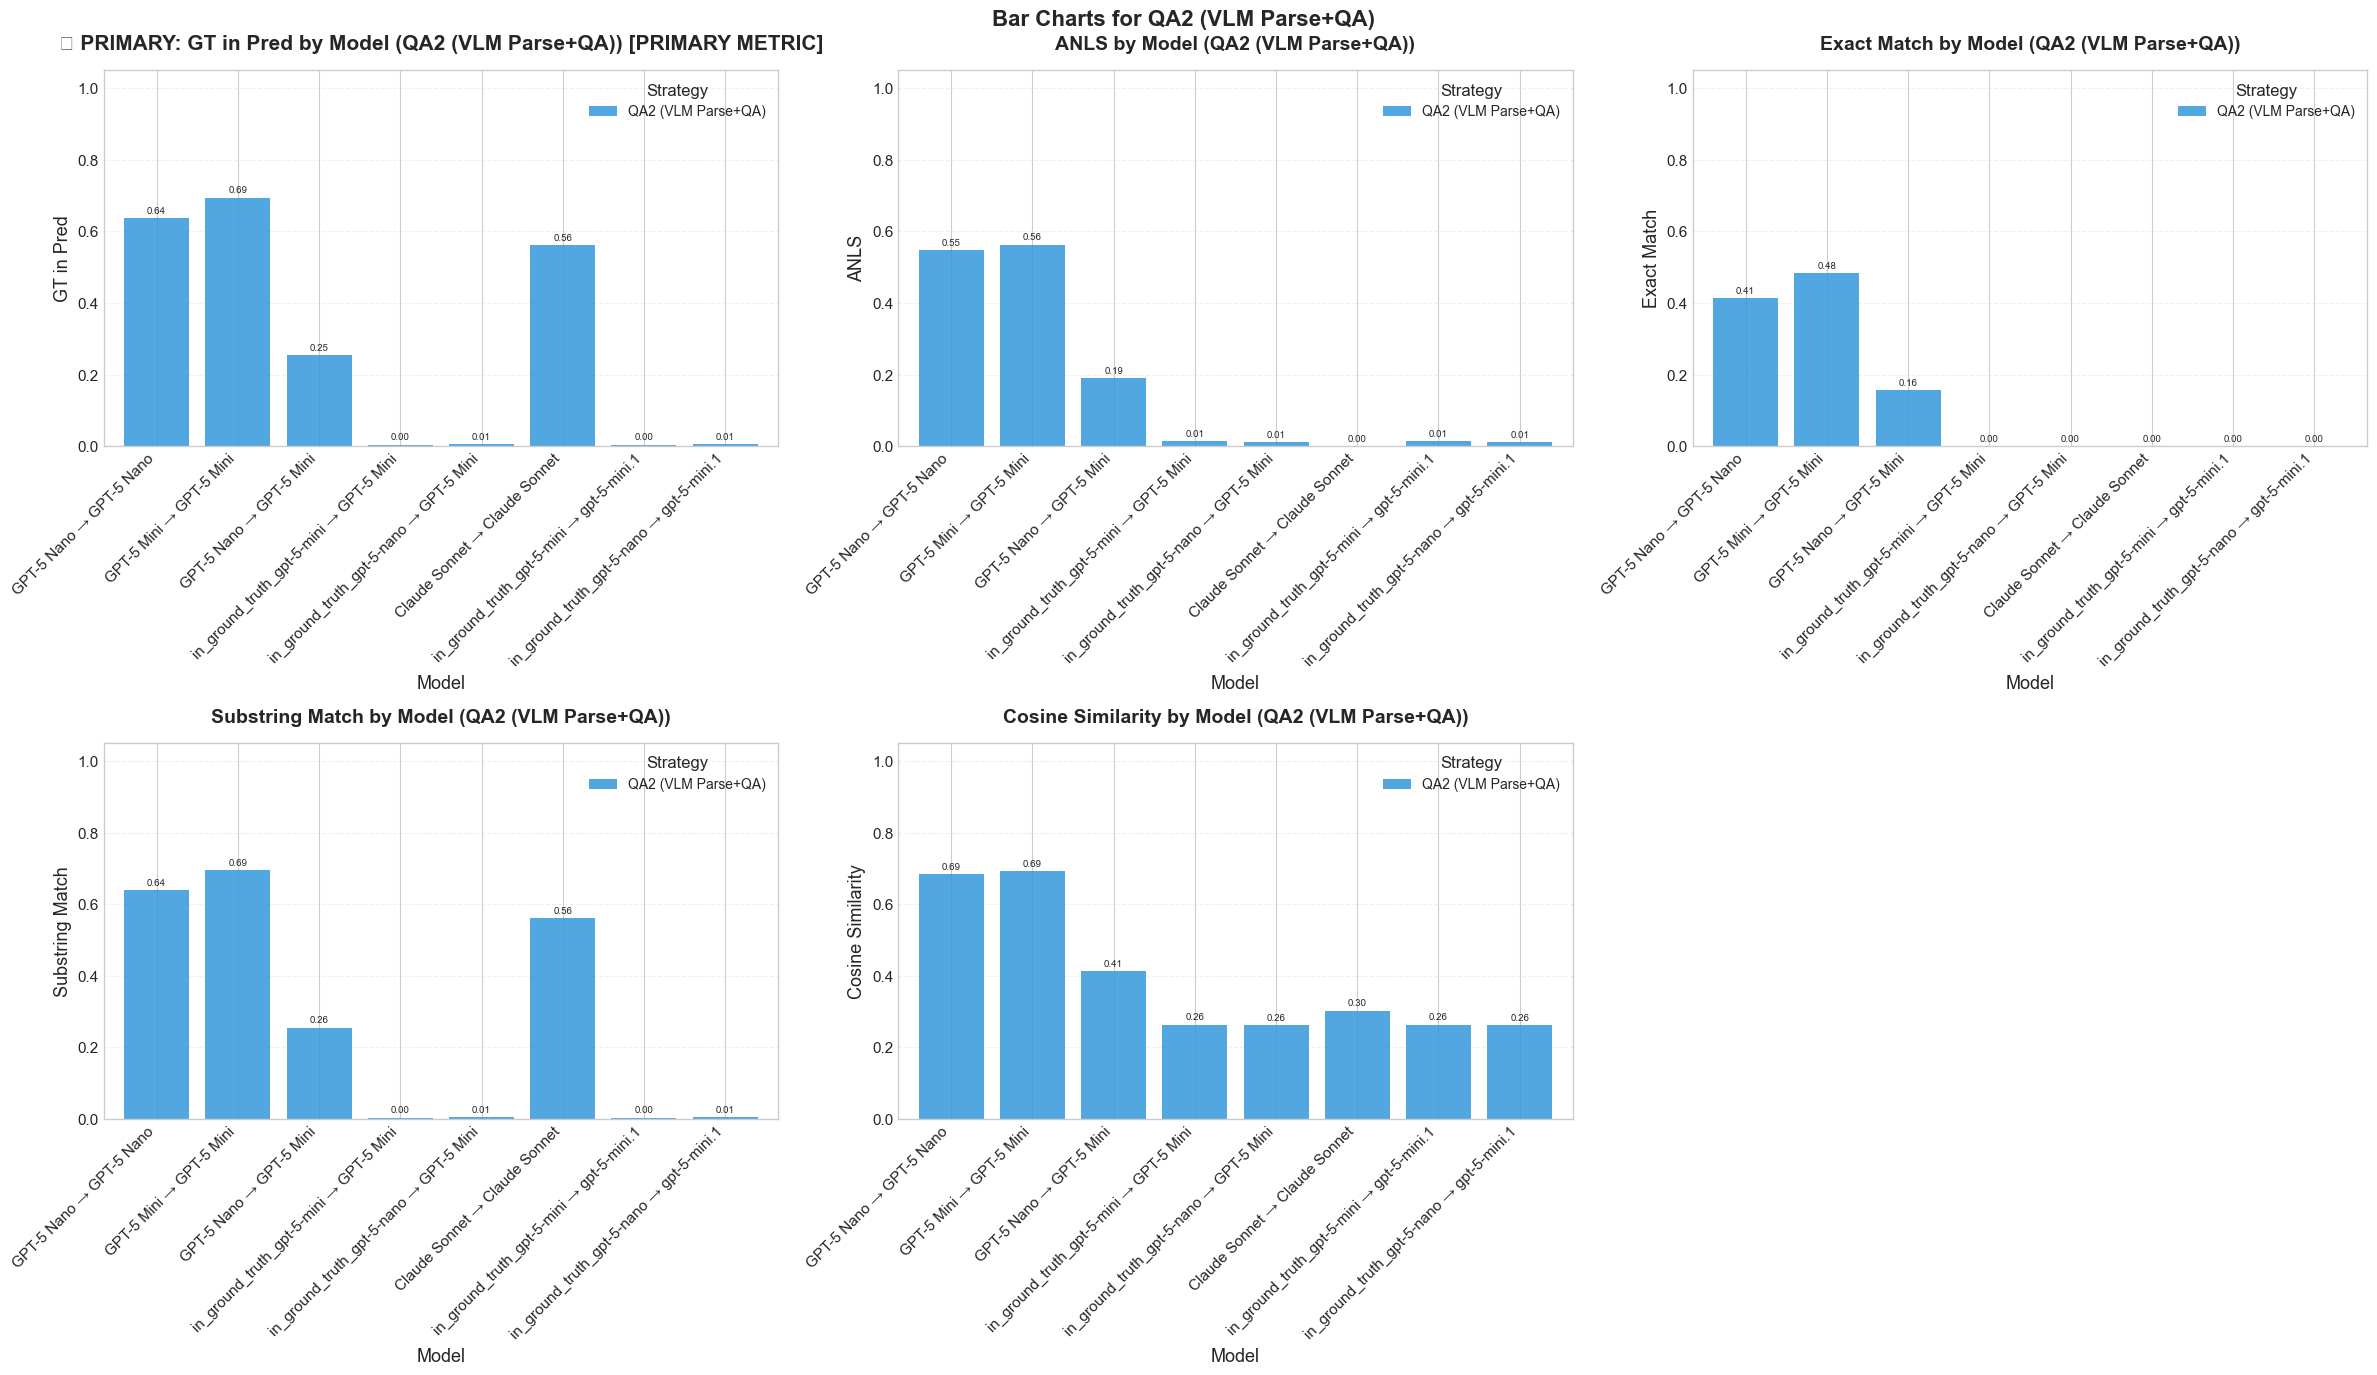

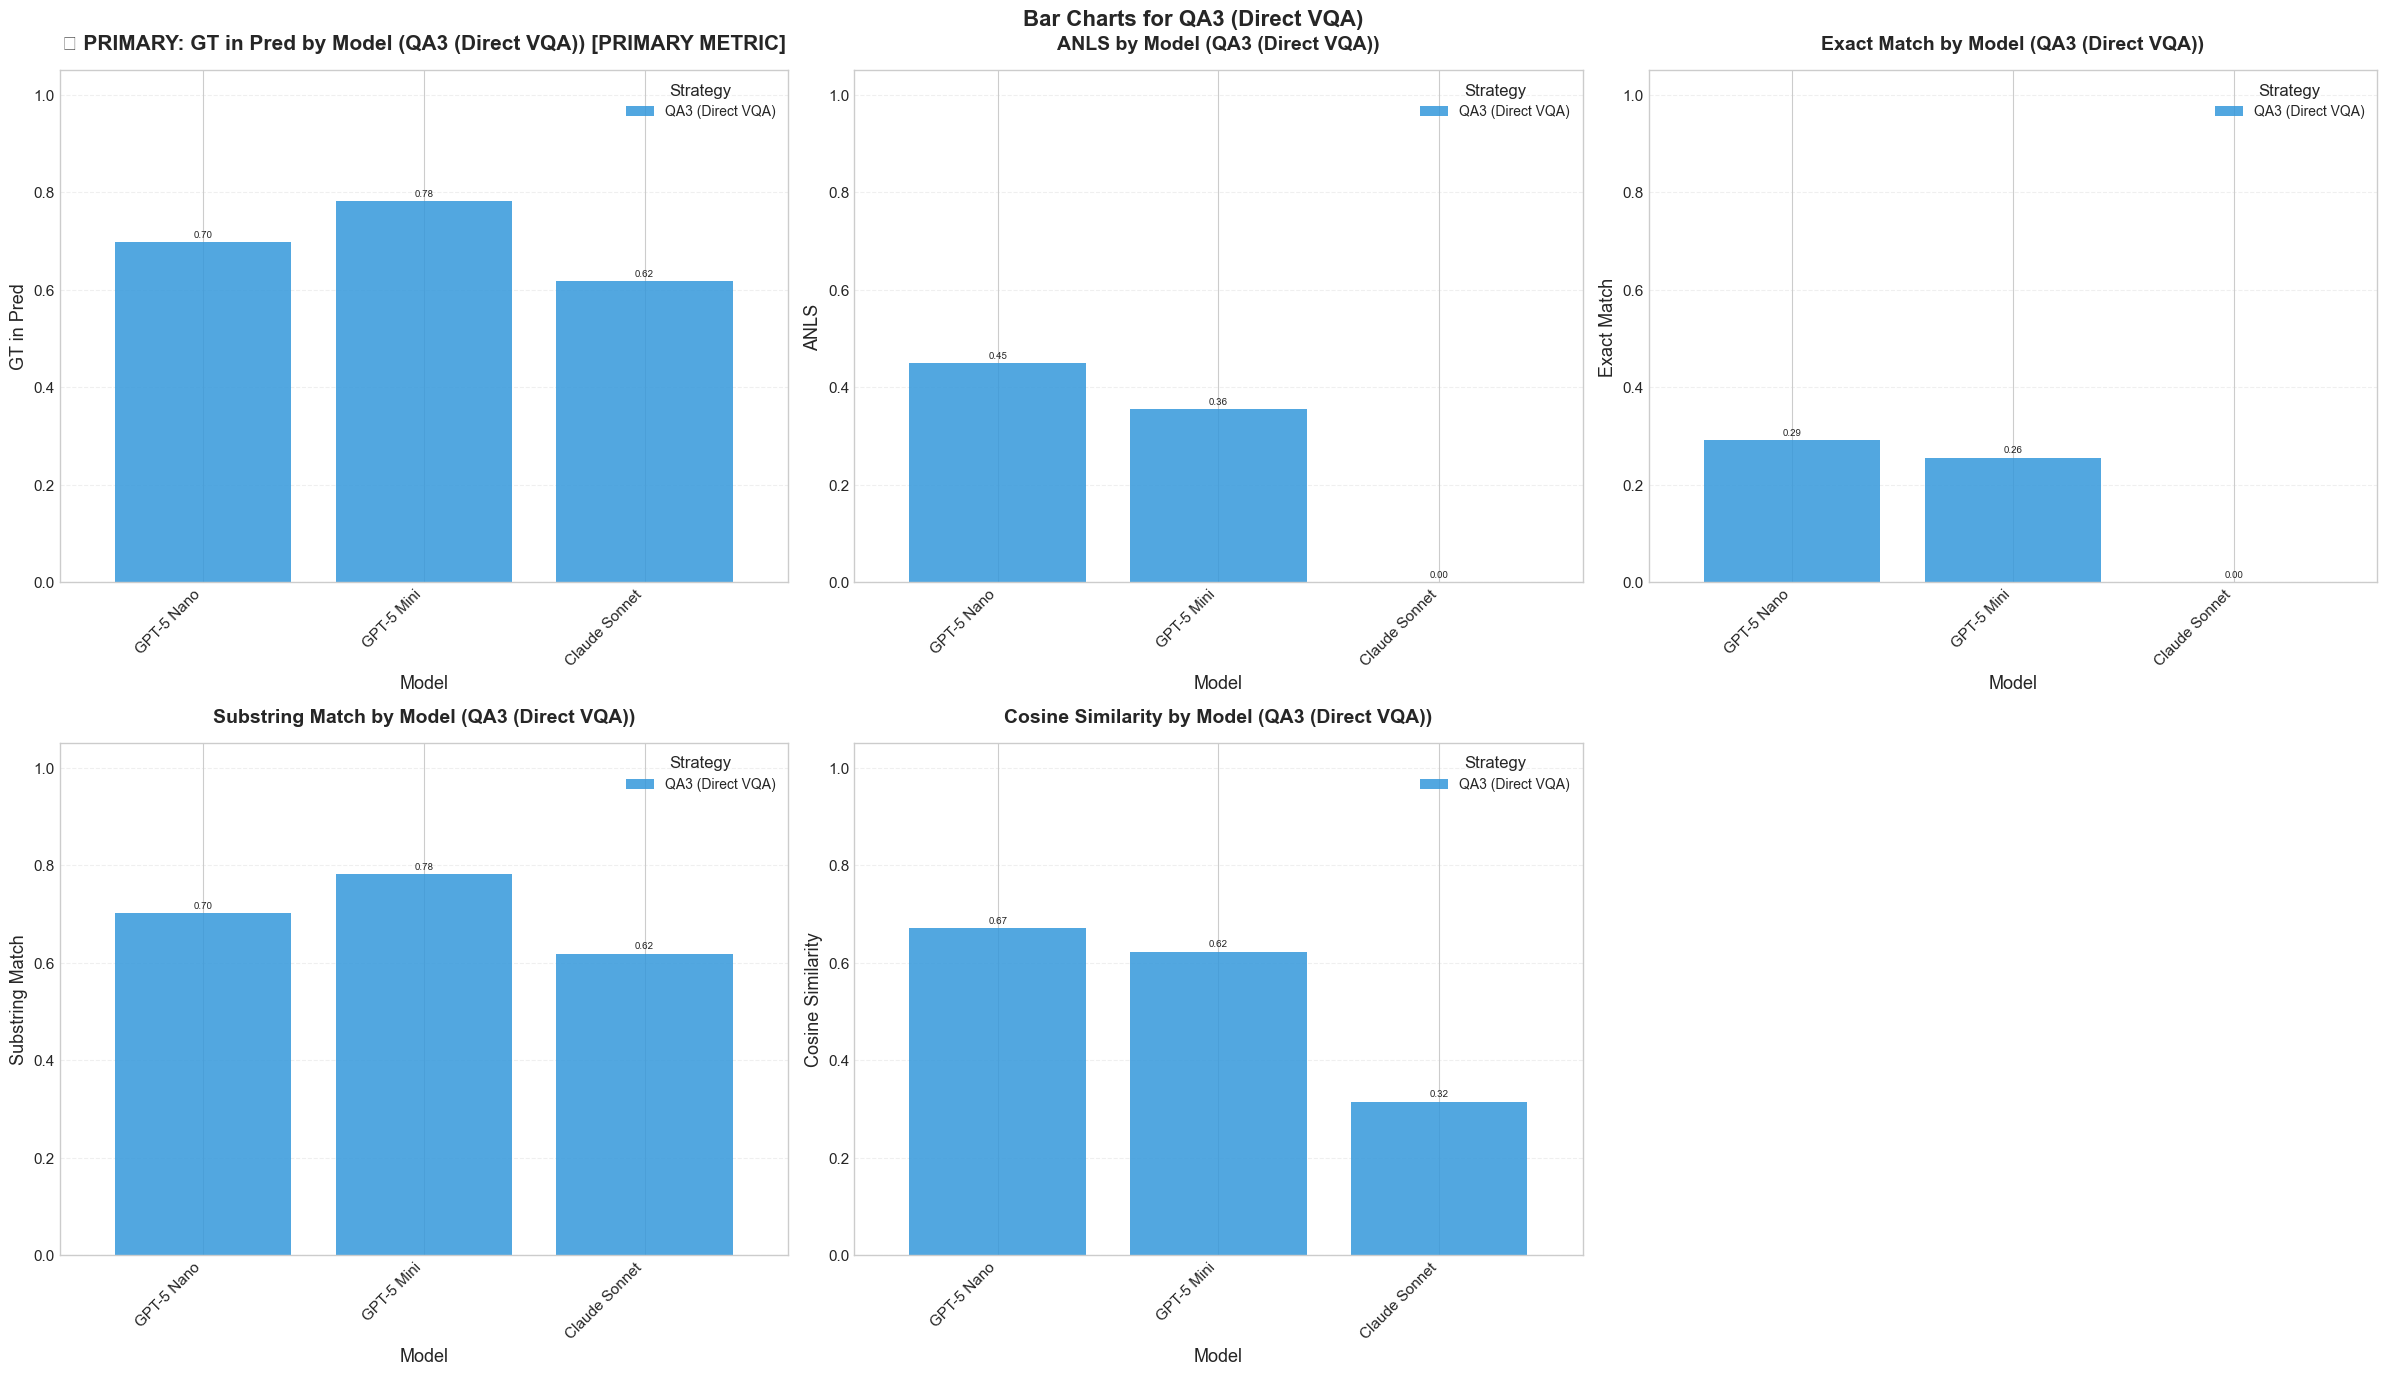


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


In [ ]:
# Bar charts for each metric (PRIMARY METRIC FIRST) - one figure per strategy
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#16a085', '#c0392b']

for strategy in strategies:
    # Filter data for this strategy
    strategy_df = summary_df[summary_df['Strategy'] == strategy]
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Group by Model and Strategy, then take mean to handle duplicates
        grouped_df = strategy_df.groupby(['Model', 'Strategy'])[metric].mean().reset_index()
        
        # Pivot data for grouped bar chart
        pivot_data = grouped_df.pivot(index='Model', columns='Strategy', values=metric)
        
        # Sort models
        pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
        
        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], alpha=0.85, width=0.8)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
        
        ax.set_title(f'{title_prefix}{metric} by Model ({strategy}){title_suffix}', 
                     fontsize=15 if metric == 'GT in Pred' else 14, 
                     fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    
    # Hide last subplot if not needed
    if len(metrics_to_plot) < 6:
        axes[-1].set_visible(False)
    
    plt.suptitle(f'Bar Charts for {strategy}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


## 12. Phase Comparison Analysis

Compare the four QA strategies: OCR+VLM, VLM Parse+QA, Direct VQA, and QA4 Special Strategy.


Strategy Comparison:

QA1 (OCR+VLM):
  Mean GT in Pred: 0.4574 [PRIMARY]
  Mean ANLS: 0.3608
  Mean Exact Match: 0.2907
  Mean Substring Match: 0.4605
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  Mean GT in Pred: 0.3962 [PRIMARY]
  Mean ANLS: 0.2519
  Mean Exact Match: 0.2032
  Mean Substring Match: 0.3971
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  Mean GT in Pred: 0.6994 [PRIMARY]
  Mean ANLS: 0.2686
  Mean Exact Match: 0.1824
  Mean Substring Match: 0.7007
  Phases included: QA3a, QA3b

QA4 (Special Strategy):
  Mean GT in Pred: 0.5808 [PRIMARY]
  Mean ANLS: 0.4912
  Mean Exact Match: 0.4014
  Mean Substring Match: 0.5872
  Phases included: QA4a, QA4b, QA4c


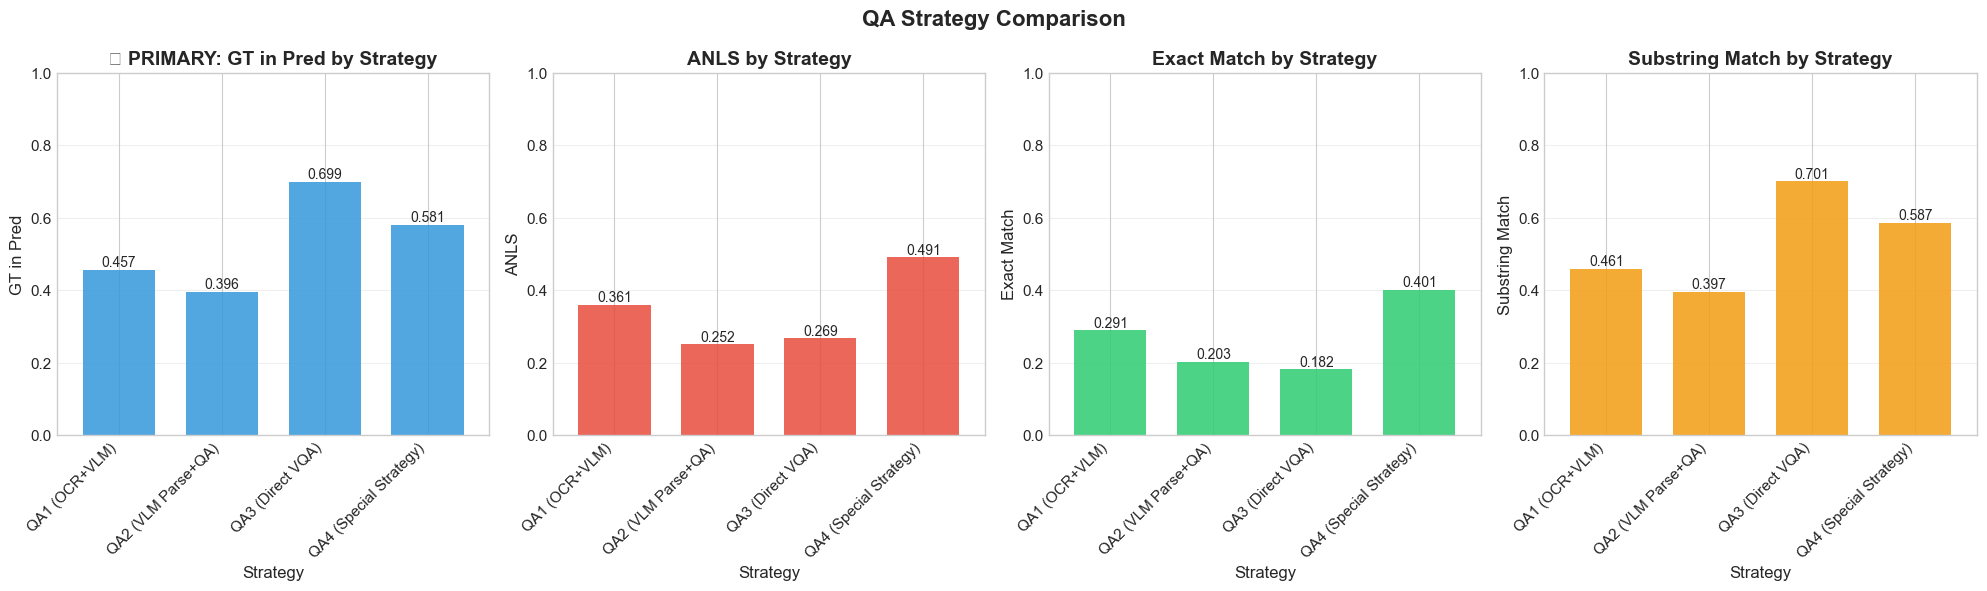

In [ ]:
from matplotlib.container import BarContainer

# Group phases by strategy (INCLUDING QA4)
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b'],
    'QA4 (Special Strategy)': ['QA4a', 'QA4b', 'QA4c']
}

print("\nStrategy Comparison:")
print("=" * 100)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()  # PRIMARY METRIC
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"  Mean ANLS: {avg_anls:.4f}")
        print(f"  Mean Exact Match: {avg_em:.4f}")
        print(f"  Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY METRIC FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison - separate plots for each metric
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    metrics = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']  # PRIMARY METRIC FIRST
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        strategy_df.set_index('Strategy')[metric].plot(
            kind='bar', ax=ax, color=colors[idx], alpha=0.85, width=0.7
        )
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} by Strategy', fontsize=14, fontweight='bold')
        ax.set_xlabel('Strategy', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylim(0, 1.0)
        
        # Add value labels
        for container in ax.containers:
            if isinstance(container, BarContainer):
                ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.suptitle('QA Strategy Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [ ]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: infovqa_mini_0002 | ANLS: 1.0000
Question: What percent of non-digitally mature healthcare providers do not use digital technologies to persona...
Ground Truths: "79%", "79"
Prediction: 79%

Sample: infovqa_mini_0003 | ANLS: 1.0000
Question: In which year Pele achieved his third World Cup?
Ground Truths: "1970"
Prediction: 1970

Sample: infovqa_mini_0004 | ANLS: 1.0000
Question: What % of US adults will develop a mental illness during their lifetime
Ground Truths: "50", "50%"
Prediction: 50%

Sample: infovqa_mini_0005 | ANLS: 1.0000
Question: What percentage of companies use social media for marketing?
Ground Truths: "89%", "89"
Prediction: 89%

Sample: infovqa_mini_0007 | ANLS: 1.0000
Question: What percent of help in Israel comes from charities and social services?
Ground Truths: "59%", "59"
Prediction: 59%

Sample: infovqa_mini_0010 | ANLS: 1.0000
Question: What percent of the U.S. working population

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Strategy,Model,Mean Time (ms),Median Time (ms)
2,QA1a,mistral_ocr_3__gpt-5-mini,9986.507437,9450.701118
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156
5,QA1b,mistral_ocr_3__gpt-5-mini,7176.615162,6458.381414
4,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332
3,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958
6,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377
8,QA1c,mistral_ocr_3__gpt-5-mini,10800.276764,10126.909494
7,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021
9,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000


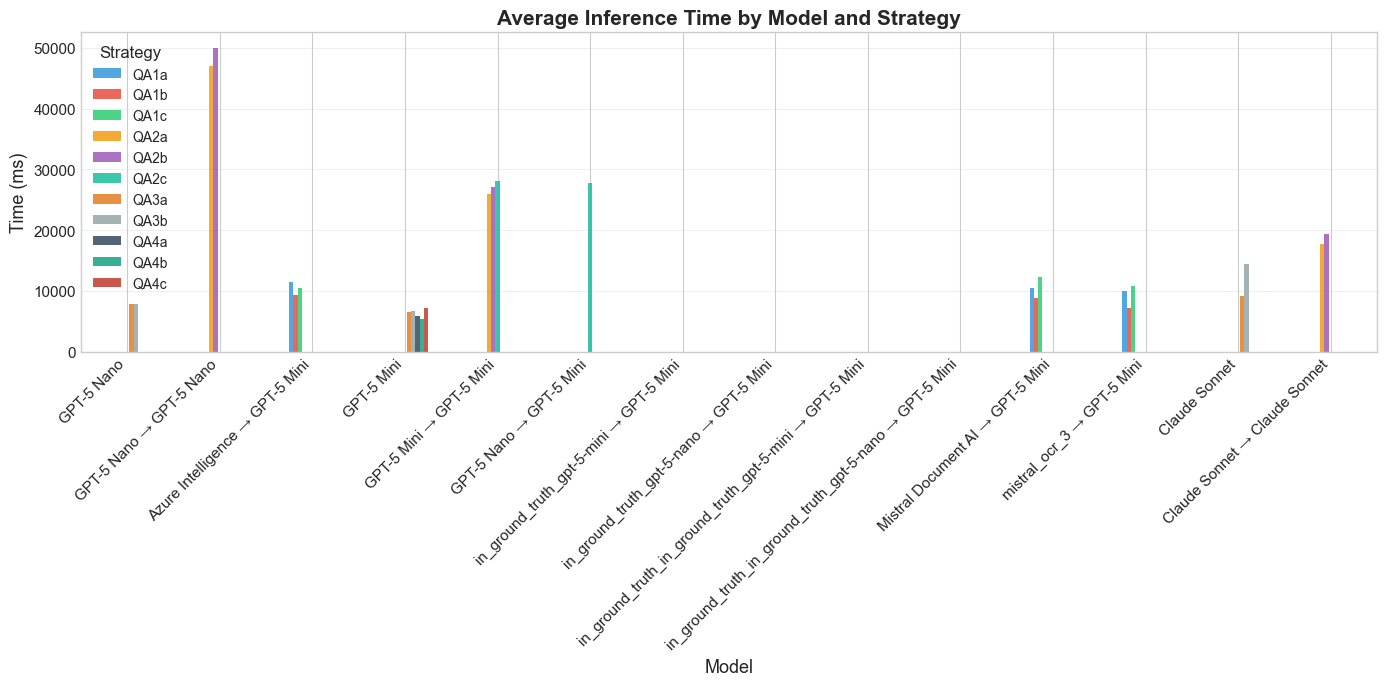

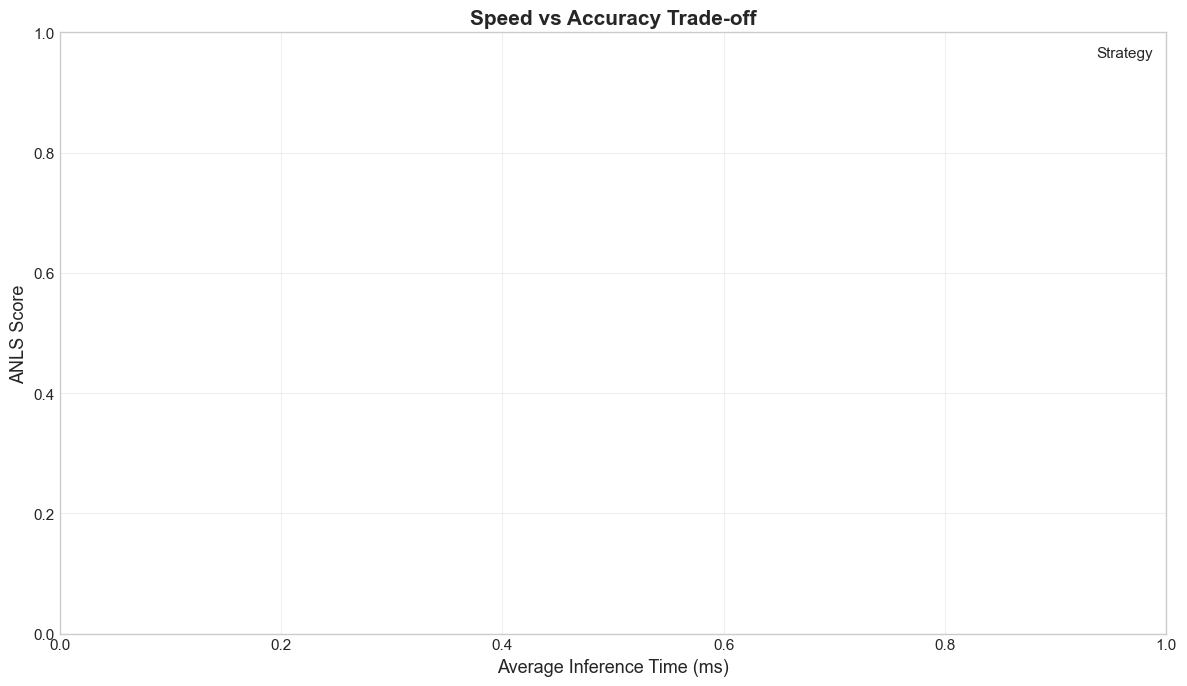

In [ ]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Strategy': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Strategy', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 7))
    
    pivot_time = inference_df.pivot(index='Model', columns='Strategy', values='Mean Time (ms)')
    pivot_time = pivot_time.reindex(sort_models(pivot_time.index.tolist()))
    pivot_time.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Strategy', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with ANLS scores
    speed_accuracy = pd.merge(
        inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
        summary_df[['Strategy', 'Model', 'ANLS']],
        on=['Strategy', 'Model']
    )
    
    for phase in speed_accuracy['Strategy'].unique():
        phase_data = speed_accuracy[speed_accuracy['Strategy'] == phase]
        ax.scatter(phase_data['Mean Time (ms)'], phase_data['ANLS'], 
                  s=150, alpha=0.7, label=phase)
    
    ax.set_title('Speed vs Accuracy Trade-off', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('ANLS Score', fontsize=13)
    ax.legend(title='Strategy', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 15. InfographicVQA-Specific Analysis

Analyze infographic-specific patterns: chart types, visual reasoning vs text extraction, and QA4 special strategy comparison.

In [ ]:
# Analyze performance on infographic-specific patterns
print("\nInfographicVQA-Specific Analysis:")
print("=" * 100)
print("\nKey Findings:")
print("- Infographic questions involve charts, statistics, and visual design elements")
print("- Questions require both text extraction and visual reasoning")
print("- Chart types may include bar charts, pie charts, line graphs, and infographic layouts")
print("\nQA4 Special Strategy Comparison:")

# Compare QA4 with other strategies
if 'QA4a' in summary_df['Phase'].values or 'QA4b' in summary_df['Phase'].values or 'QA4c' in summary_df['Phase'].values:
    qa4_data = summary_df[summary_df['Phase'].str.startswith('QA4')]
    other_data = summary_df[~summary_df['Phase'].str.startswith('QA4')]
    
    print(f"\nQA4 Strategy Performance:")
    print(f"  Average GT in Pred: {qa4_data['GT in Pred'].mean():.4f} [PRIMARY]")
    print(f"  Average ANLS: {qa4_data['ANLS'].mean():.4f}")
    print(f"  Average Exact Match: {qa4_data['Exact Match'].mean():.4f}")
    
    print(f"\nOther Strategies (QA1-QA3) Performance:")
    print(f"  Average GT in Pred: {other_data['GT in Pred'].mean():.4f} [PRIMARY]")
    print(f"  Average ANLS: {other_data['ANLS'].mean():.4f}")
    print(f"  Average Exact Match: {other_data['Exact Match'].mean():.4f}")
    
    improvement = ((qa4_data['GT in Pred'].mean() - other_data['GT in Pred'].mean()) / other_data['GT in Pred'].mean()) * 100
    print(f"\n🎯 QA4 vs Others (GT in Pred): {improvement:+.1f}% {'improvement' if improvement > 0 else 'decline'}")
else:
    print("  No QA4 data available for comparison")

print("\nRecommendations for infographic QA:")
print("- Direct VQA (QA3) may excel at visual reasoning questions")
print("- OCR pipeline (QA1) can be effective for text-heavy infographics")
print("- Consider QA4 special strategy for complex chart understanding")
print("- Evaluate model performance on different chart types if metadata available")


InfographicVQA-Specific Analysis:

Key Findings:
- Infographic questions involve charts, statistics, and visual design elements
- Questions require both text extraction and visual reasoning
- Chart types may include bar charts, pie charts, line graphs, and infographic layouts

QA4 Special Strategy Comparison:

QA4 Strategy Performance:
  Average GT in Pred: 0.5808 [PRIMARY]
  Average ANLS: 0.4912
  Average Exact Match: 0.4014

Other Strategies (QA1-QA3) Performance:
  Average GT in Pred: 0.4840 [PRIMARY]
  Average ANLS: 0.2919
  Average Exact Match: 0.2277

🎯 QA4 vs Others (GT in Pred): +20.0% improvement

Recommendations for infographic QA:
- Direct VQA (QA3) may excel at visual reasoning questions
- OCR pipeline (QA1) can be effective for text-heavy infographics
- Consider QA4 special strategy for complex chart understanding
- Evaluate model performance on different chart types if metadata available


## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
Saving embeddings for modified phases: {'QA1b', 'QA1a', 'QA1c'}
✅ Saved: QA1b_embeddings_text-embedding-3-large_20260204_114406.json
✅ Saved: QA1a_embeddings_text-embedding-3-large_20260204_114411.json
✅ Saved: QA1c_embeddings_text-embedding-3-large_20260204_114415.json

✅ All embeddings have been persisted to disk!
